# Auto-EDA: Productividad vs. Criterio de Ingeniería

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/02_eda/09_auto_eda_y_criterio.ipynb)

## Objetivos


- Aprender a generar reportes exploratorios masivos y automatizados utilizando frameworks de Auto-EDA como `ydata-profiling`.
- Comprender el costo computacional de estas herramientas y cómo aplicarlas en datasets de gran escala.
- **Desarrollar escepticismo profesional:** Aprender a auditar críticamente las "alertas automáticas" de la herramienta aplicando lógica de negocio y conocimiento del dominio.



## Prerrequisitos


- Haber completado el bloque principal de EDA (Notebooks 01 al 08).
- Comprensión sólida de los conceptos de [Correlación y Asociación](03_analisis_correlacion_y_asociacion.ipynb).

---


## Configuración del Entorno



***Nota**: Las herramientas de Auto-EDA suelen requerir instalación adicional si no están en el entorno base.*

***En la celda de abajo, se detecta automáticamente y se intenta instalar.***

**Nota2**: En entornos locales, este tipo de *frameworks* los recomiendo instalar en un entorno virtual dedicado, así no se "rompen" otras cosas. Suelen usar muchas dependencias con versiones muy concretas...


In [1]:
# @title *Esta celda instala dependencias, clona el repositorio e importa utilidades*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Ejecución en Google Colab. Instalando dependencias y clonando repositorio...")
    import subprocess
    # Instalamos ydata-profiling silenciosamente
    subprocess.run(["pip", "install", "-q", "ydata-profiling"], check=True)

    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

Ejecución en Google Colab. Instalando dependencias y clonando repositorio...


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
from utils.data import load_dataset

import warnings
warnings.filterwarnings('ignore')

## Introducción Teórica



A lo largo de este capítulo, invertimos horas escribiendo código para generar histogramas, detectar nulos, calcular matrices de correlación y buscar *outliers*. Este proceso manual es vital para desarrollar intuición, pero en el mundo corporativo, **el tiempo es dinero**.

¿Qué pasaría si te digo que una librería puede hacer el 80% de ese trabajo en 10 segundos?

Los *frameworks* de **Auto-EDA** (como `ydata-profiling`, `Sweetviz`, `D-Tale`... hay muchos, conviene investigarlos) toman un DataFrame y devuelven un reporte HTML interactivo exhaustivo. Sin embargo, traen consigo un peligro inmenso que tienen en común este tipo de *frameworks*: **la ilusión de la automatización**. Estas herramientas calculan estadísticas, no entienden el contexto físico ni el modelo de negocio o problema que se está atacando (con objetivos y necesidades muy concretas).

> ⚠️ **Regla de Oro del Auto-EDA:** La herramienta es una brújula, no el piloto. Las alertas que genera deben ser auditadas siempre por el criterio de un ingeniero.

## 1. Generación del Reporte Automático



Para este caso de estudio, utilizamos el dataset **ADL (Air Quality)**. Este dataset contiene lecturas de una matriz de sensores de gas IoT (Internet de las Cosas) de bajo costo, cuyo objetivo es predecir qué actividad se está realizando en una habitación (ej. cocinar, limpiar, presencia de humo).



In [3]:
# Carga de datos usando nuestra utilidad
dataset_path = "datasets/adl/datos_adl.csv"
df_adl = load_dataset(dataset_path)

print(f"Dimensiones del dataset: {df_adl.shape}")
df_adl.head()

Archivo CSV no encontrado. Descomprimiendo /content/applied-ai-engineering/datasets/adl/datos_adl.zip...
Descompresión completa. Intentando cargar el CSV.
Dataset cargado exitosamente con 1845 filas y 7 columnas.
Dimensiones del dataset: (1845, 7)


,MQ2,MQ9,MQ135,MQ137,MQ138,MG-811,Situacion
0,670,696,1252,1720,1321,2431,4
1,641,674,1156,1652,1410,2433,4
2,642,646,1159,1643,1455,2361,4
3,640,590,1105,1608,1459,2427,4
4,616,627,1192,1637,1466,2447,4



Vamos a generar el reporte. En un entorno local, esto creará un archivo `.html` interactivo. En un Jupyter Notebook o Colab, podemos incrustarlo directamente.



In [4]:
# Generamos el reporte de perfilado
# Nota: title es el título del reporte, explorative=True activa cálculos más profundos
reporte = ProfileReport(df_adl,
                        title="Reporte de Calidad del Aire (ADL)",
                        dataset={"description": "Esta es una descriptión del dataset, opcional por supuesto...",
                                 "copyright_holder": "Ing. Axel Skrauba",
                                 "copyright_year": "2026",
                                },
                        explorative=True)

# Para visualizarlo dentro del notebook (puede tardar unos segundos en renderizar)
reporte.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:00<00:00, 57.08it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]


*(Si estás ejecutando esto, dedicar el tiempo que amerita para navegar por las pestañas del reporte generado arriba: Overview, Variables, Interactions, Correlations, Missing values).* Identificar las gráficas y métricas expuestas, compararlas con las que vimos antes, interpretar resultados...


In [5]:
# Se puede guardar el reporte, como un archivo html interactivo completo
# Así se puede analizar, compartir y demás. Notar que apuntan a la "reproducibilidad" completa

# Descomentar abajo para exportar
# reporte.to_file("reporte_adl_auto_eda.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## 2. El Peligro de la Automatización: Auditando las Alertas


Si vas a la pestaña **"Alerts"** (Alertas) del reporte generado, notarás que `ydata-profiling` está "gritando" advertencias en rojo. Se ven mensajes como:

*   *`MG-811` is highly overall correlated with `Situacion`*
*   *`MQ135` is highly overall correlated with `MQ137` and `4 other fields`*
*   *`Dataset` has `11 (0.6%)` duplicate rows*
*   ... *entre otros*

Un analista junior, al ver esto, recordaría sus clases de estadística básica: *"La multicolinealidad es mala para los modelos lineales. Debo eliminar las variables redundantes"*. Y procedería a borrar `MQ9`, `MQ135` y `MQ138`, dejando solo un par de sensores.

**Aquí es donde entra el Criterio de Ingeniería.**

### El Contexto Físico (*Domain Knowledge*)


Si buscamos y leemos la documentación técnica de los sensores de *hardware* que componen nuestro *dataset*, vamos a encontrar que:
- **MQ2:** Sensible a gases combustibles (Metano, Butano, GLP).
- **MQ9:** Sensible al Monóxido de Carbono (CO) y gases combustibles.
- **MQ135:** Sensible al Amoníaco, Sulfuro, Benceno (calidad del aire general).
- **MQ137:** Sensible específicamente al Amoníaco (NH3).

Es **físicamente obvio** que estarán altamente correlacionados. Si hay un incendio (Situación 3: Humo), se liberará tanto CO como gases combustibles, haciendo que el MQ2 y el MQ9 disparen sus valores al mismo tiempo.

Pero, ¿son redundantes? Lo podemos comprobar visualmente:

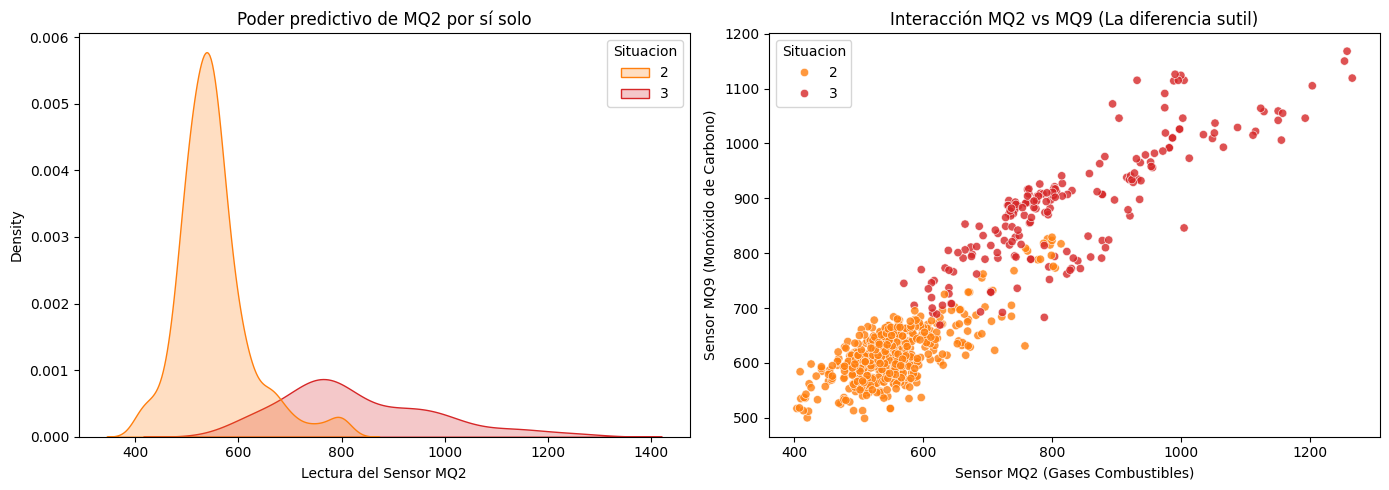

In [6]:
# Filtramos solo las situaciones de "Cocinar" (2) y "Humo" (3)
df_subset = df_adl[df_adl['Situacion'].isin([2, 3])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Solo usando MQ2
sns.kdeplot(data=df_subset, x='MQ2', hue='Situacion', palette=['#ff7f0e', '#d62728'], fill=True, ax=axes[0])
axes[0].set_title("Poder predictivo de MQ2 por sí solo")
axes[0].set_xlabel("Lectura del Sensor MQ2")

# Gráfico 2: La relación entre MQ2 y MQ9
sns.scatterplot(data=df_subset, x='MQ2', y='MQ9', hue='Situacion', palette=['#ff7f0e', '#d62728'], alpha=0.8, ax=axes[1])
axes[1].set_title("Interacción MQ2 vs MQ9 (La diferencia sutil)")
axes[1].set_xlabel("Sensor MQ2 (Gases Combustibles)")
axes[1].set_ylabel("Sensor MQ9 (Monóxido de Carbono)")

plt.tight_layout()
plt.show()


**Análisis de Ingeniería:**

1. Observar el gráfico de la izquierda. Si hacemos caso a la herramienta y nos quedamos **solo** con el `MQ2`, las distribuciones de "Cocinar" (naranja) y "Humo" (rojo) se solapan muchísimo. El modelo se confundirá constantemente entre alguien haciendo un buen asado y la casa incendiándose.
2. Observar el gráfico de la derecha. Aunque la correlación es casi una línea recta perfecta (alta correlación), **la pendiente es ligeramente distinta para cada clase**. El humo produce una proporción diferente de CO respecto a los gases combustibles que la simple cocción.

**Conclusión:** Si hubiéramos borrado el `MQ9` basándonos ciegamente en la alerta de Auto-EDA, habríamos destruido la capacidad del modelo para salvar vidas en caso de incendio. La alta correlación no siempre implica redundancia inútil; a veces, la "diferencia" entre dos variables correlacionadas es exactamente la señal que el modelo necesita.

## 3. Costo Computacional y Escalabilidad



El *dataset* ADL tiene ~1800 filas. El reporte se generó en segundos.
Pero, ¿qué pasa si trabajamos en un banco con un *dataset* de transacciones de **15 millones de filas** y 200 columnas?

Si ejecutamos `ProfileReport(df)` en ese *dataset*:
1. La memoria RAM se saturará (Error `Out of Memory - OOM`).
2. El cálculo de correlaciones cruzadas ($200 \times 200$ combinaciones) tardará horas.
3. El archivo HTML resultante pesará cientos de megabytes y se "colgará" el navegador web tratando de renderizar todo.



### Estrategias de Mitigación en Producción


Cuando el problema sea del tipo Big Data, el Auto-EDA puede usarse, pero con restricciones:

**A. Modo Mínimo (Minimal Mode):**
Desactiva los cálculos costosos (como las correlaciones complejas y las interacciones) y solo calcula estadísticas univariadas básicas.

In [ ]:
# reporte_rapido = ProfileReport(df_gigante, minimal=True)


**B. Muestreo Aleatorio (Random Sampling):**
No se necesitan las 15 millones de filas para saber si una variable tiene asimetría o nulos. Una muestra representativa del `5%` suele ser estadísticamente idéntica a la población total para fines exploratorios (es un ejemplo, no tomar el `5%` como literal, aplicar lo visto en estadística para muestreo representativo).


In [ ]:
# Tomamos una muestra aleatoria de 100.000 filas
# df_muestra = df_gigante.sample(n=100000, random_state=42)
# reporte_muestra = ProfileReport(df_muestra)

## Resultados y Discusión



Las herramientas de Auto-EDA son un multiplicador de fuerza para el ingeniero de IA. Permiten saltar la fase de "escribir código repetitivo" y pasar directamente a la fase de "pensar" (que para esto no hay un *framework*).

Sin embargo, demostramos empíricamente que:
1. Las alertas automáticas (como la alta correlación) son advertencias estadísticas, no verdades absolutas (hay que entender el problema/negocio).
2. Eliminar variables sin entender la física o la lógica detrás de ellas puede destruir el poder predictivo del sistema.
3. El uso de estas herramientas requiere gestión de recursos computacionales (RAM y CPU) cuando se escala a entornos de producción.

## Conexiones y Próximos Pasos


- ➡️ **Siguiente:** El Auto-EDA genera gráficos estándar, pero a la hora de presentar resultados a un cliente o directorio (o informe, paper, presentación, etc.), se necesitan gráficos a medida que cuenten una historia y presenten de manera efectiva y estética la información. Lo vemos brevemente en [Visualización Efectiva y Storytelling](10_visualizacion_efectiva.ipynb).
- 🔄 **Relacionado:** En el Capítulo 3, retomamos este *dataset* de sensores IoT para ver cómo un algoritmo de *Feature Selection* (RFE) evalúa matemáticamente si podemos apagar algunos sensores para ahorrar batería, validando nuestra intuición de hoy.

## Referencias


1. [Documentación Oficial de ydata-profiling](https://docs.profiling.ydata.ai/latest/)
2. Gambi, E. (2020). *Air Quality dataset for ADL classification*. Mendeley Data.

---


## Entorno de Ejecución


In [8]:
from utils.environment import environment_table
environment_table(include_all=True)

Package,Version
Python,3.12.12
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
Cython,3.0.12
IPython,7.34.0
PIL,11.3.0
anywidget,0.9.21
argparse,1.1
attr,25.4.0
backcall,0.2.0
bottleneck,1.4.2
